In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matchms
import pickle

In [3]:
filename = "gnps_positive_ionmode_unique_inchikey_cleaned_by_matchms_and_lookups.json"
reference_spectrums_lookup = matchms.importing.load_from_json(f"src/data/{filename}")

In [4]:
from matchms.filtering import normalize_intensities
from matchms.filtering import require_minimum_number_of_peaks
from matchms.filtering import select_by_mz
from matchms.filtering import select_by_relative_intensity

def post_process(s):
    s = normalize_intensities(s)
    s = select_by_mz(s, mz_from=0, mz_to=1000)
    s = require_minimum_number_of_peaks(s, n_required=10)
    s = select_by_relative_intensity(s, intensity_from=0.01, intensity_to=1.0)
    return s

In [5]:
# apply filters to the data
spectrums = [post_process(s) for s in reference_spectrums_lookup]

# omit spectrums that didn't qualify for analysis
spectrums = [s for s in spectrums if s is not None]

In [6]:
print("Remaining number of spectra:", len(spectrums))

Remaining number of spectra: 4993


In [7]:
from matchms.filtering.add_fingerprint import add_fingerprint

spectrums = [add_fingerprint(s, fingerprint_type="daylight", nbits=2048) for s in spectrums]

In [8]:
for i, spec1 in enumerate(spectrums):
    if spec1.get("fingerprint") is None:
        print(i, "no fingerprint")
    elif spec1.get("fingerprint").sum() < 1:
        print(i, "weird")

In [9]:
from matchms.similarity import FingerprintSimilarity

similarity_measure = FingerprintSimilarity(similarity_measure="jaccard")
scores_mol_similarity = similarity_measure.matrix(spectrums, spectrums)

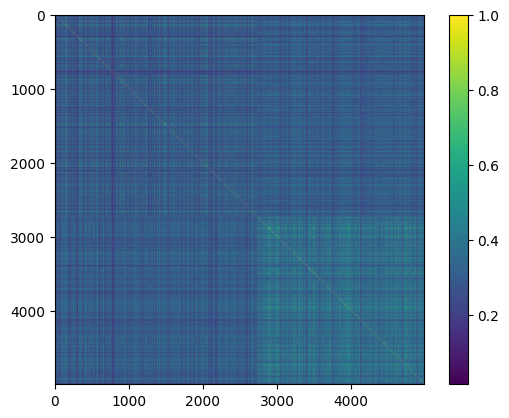

In [10]:
plt.imshow(scores_mol_similarity, cmap="viridis")
plt.colorbar()
plt.show()

In [11]:
n = len(scores_mol_similarity)
row_indices, col_indices = np.triu_indices(n, k=1)

vals = scores_mol_similarity[row_indices, col_indices]
vals

array([1.        , 0.29147287, 0.29147287, ..., 1.        , 0.29602356,
       0.29602356])

In [12]:
print(np.count_nonzero(vals == 1))

3337


In [13]:
mask = np.isclose(vals, 1.0)

In [14]:
i_ones = row_indices[mask]
j_ones = col_indices[mask]

In [15]:
print(i_ones)
print(j_ones)

[   0    2    4 ... 4989 4989 4990]
[   1    3    5 ... 4990 4991 4991]


## Gaussian Kernel for comparing spectra

$$ k(p_i, p_j') = \exp(-\frac{(p_i - p_j')^2}{2 \sigma^2}) $$
$$ K(X, Y) = \sum_{i=1}^{n} \sum_{j=1}^{m} w_i v_j k(p_i, p_j') $$
$$ S(X, Y) = \frac{K(X, Y)}{K(X, X) + K(Y, Y) - K(X, Y)} $$

In [16]:
# # implementing gaussian kernel

# def gauss_kernel(mz1, mz2, sigma):
#   return np.exp(-(mz1 - mz2)**2 / (2 * sigma**2))

# def distance(X, Y, sigma):
#   d = 0
#   n = X.peaks.mz.shape[0]
#   m = Y.peaks.mz.shape[0]
#   for i in range(n):
#     for j in range(m):
#       w = X.peaks.intensities[i]
#       v = Y.peaks.intensities[j]
#       d += w * v * gauss_kernel(X.peaks.mz[i], Y.peaks.mz[j], sigma)
#   return d

# def normalized_distance(X, Y, sigma=1):
#   return distance(X, Y, sigma) / (distance(X, X, sigma) + distance(Y, Y, sigma) - distance(X, Y, sigma))

In [17]:
# normalized_distance(spectrums[0], spectrums[1], sigma=2)

In [18]:
# too heavy

# gauss_sim_matrix = [normalized_distance(spectrum1, spectrum2, sigma=2) 
#   for spectrum1 in spectrums for spectrum2 in spectrums]

In [19]:
print(len(spectrums), np.mean([len(s.peaks.mz) for s in spectrums]))

4993 76.19887842980172


In [20]:
# Gaussian kernel (vectorized)
def kernel(mz_x, mz_y, sigma):
    """
    mz_x: (n,)
    mz_y: (m,)
    sigma: float
    returns (n, m) kernel matrix
    """
    diff = mz_x[:, None] - mz_y[None, :]
    return np.exp(-(diff ** 2) / (2 * sigma ** 2))


# Fast unnormalized similarity
def vec_distance(mz_x, inten_x, mz_y, inten_y, sigma):
    K = kernel(mz_x, mz_y, sigma)
    return np.sum(K * inten_x[:, None] * inten_y[None, :])

# Normalized similarity
def vec_normalized_distance(mz_x, inten_x, mz_y, inten_y, sigma=2):
    num = vec_distance(mz_x, inten_x, mz_y, inten_y, sigma)
    den = vec_distance(mz_x, inten_x, mz_x, inten_x, sigma) + \
        vec_distance(mz_y, inten_y, mz_y, inten_y, sigma) - \
        vec_distance(mz_x, inten_x, mz_y, inten_y, sigma) 
    
    return num / den if den > 0 else 0.0

# # Pre-extract spectra
# mz_list = [s.peaks.mz for s in spectrums]
# int_list = [s.peaks.intensities for s in spectrums]

# n = len(spectrums)

# # Compute symmetric similarity matrix 
# gauss_sim_matrix = np.zeros((n, n), dtype=np.float32)

# for i in range(n):
#     # diagonal = 1 by definition
#     gauss_sim_matrix[i, i] = 1.0

#     for j in range(i + 1, n):
#         sim = vec_normalized_distance(
#             mz_list[i], int_list[i],
#             mz_list[j], int_list[j],
#             sigma=2
#         )

#         gauss_sim_matrix[i, j] = sim
#         gauss_sim_matrix[j, i] = sim

In [ ]:
n = len(spectrums)

n_pairs = 10_000

i = np.random.randint(0, n, size=n_pairs)
j = np.random.randint(0, n, size=n_pairs)

# remove self-pairs
mask = i < j
i = i[mask]
j = j[mask]

pairs = list(zip(i, j))

In [22]:
pairs

[(np.int64(2456), np.int64(2578)),
 (np.int64(3719), np.int64(4730)),
 (np.int64(1898), np.int64(4355)),
 (np.int64(2405), np.int64(3793)),
 (np.int64(2746), np.int64(4497)),
 (np.int64(2133), np.int64(3843)),
 (np.int64(445), np.int64(1313)),
 (np.int64(1174), np.int64(4696)),
 (np.int64(2295), np.int64(2624)),
 (np.int64(871), np.int64(2763)),
 (np.int64(1405), np.int64(3174)),
 (np.int64(606), np.int64(4440)),
 (np.int64(3098), np.int64(3152)),
 (np.int64(1202), np.int64(1296)),
 (np.int64(2109), np.int64(4613)),
 (np.int64(339), np.int64(4538)),
 (np.int64(2794), np.int64(3014)),
 (np.int64(2342), np.int64(2967)),
 (np.int64(338), np.int64(2503)),
 (np.int64(619), np.int64(2782)),
 (np.int64(1136), np.int64(4477)),
 (np.int64(3666), np.int64(4763)),
 (np.int64(589), np.int64(2920)),
 (np.int64(169), np.int64(4219)),
 (np.int64(950), np.int64(1928)),
 (np.int64(770), np.int64(2769)),
 (np.int64(1897), np.int64(4778)),
 (np.int64(2013), np.int64(4148)),
 (np.int64(2208), np.int64(423

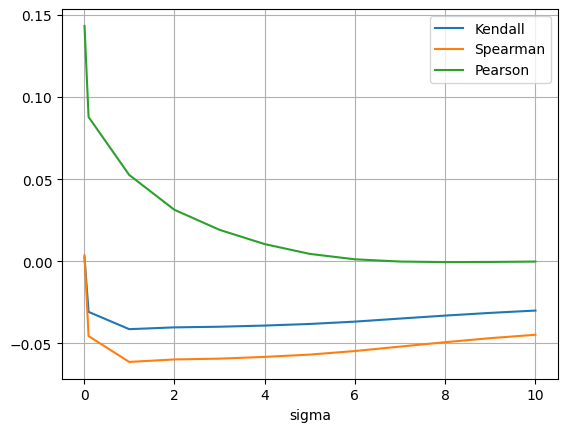

In [23]:
from scipy.stats import spearmanr, pearsonr, kendalltau

kendalls = []
spearmans = []
pearsons = []
sigmas = [0.01, 0.1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
for sigma in sigmas:
  random_pairs_jaccard = []
  random_pairs_gaussian = []
  for pair in pairs:
    random_pairs_jaccard.append(scores_mol_similarity[pair[0], pair[1]])
    random_pairs_gaussian.append(vec_normalized_distance(spectrums[pair[0]].peaks.mz,
                                                        spectrums[pair[0]].peaks.intensities,
                                                        spectrums[pair[1]].peaks.mz,
                                                        spectrums[pair[1]].peaks.intensities, sigma=sigma))
  spearmans.append(spearmanr(random_pairs_jaccard, random_pairs_gaussian)[0])
  pearsons.append(pearsonr(random_pairs_jaccard, random_pairs_gaussian)[0])
  kendalls.append(kendalltau(random_pairs_jaccard, random_pairs_gaussian)[0])

plt.plot(sigmas, kendalls, label="Kendall")
plt.plot(sigmas, spearmans, label="Spearman")
plt.plot(sigmas, pearsons, label="Pearson")
plt.legend()
plt.grid()
plt.xlabel("sigma")
plt.show()

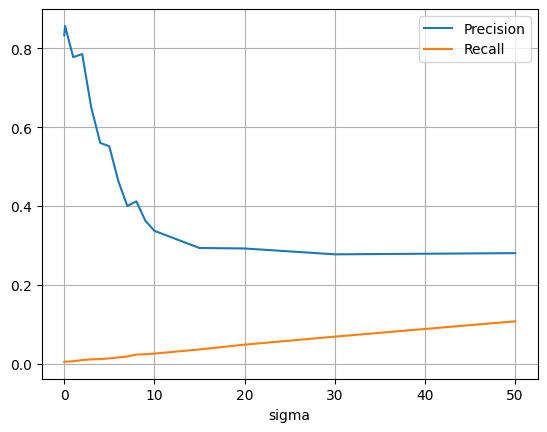

In [24]:
from sklearn.metrics import precision_score, recall_score


precisions = []
recalls = []
sigmas = [0.01, 0.1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 50]
for sigma in sigmas:
  random_pairs_jaccard = []
  random_pairs_gaussian = []
  for pair in pairs:
    random_pairs_jaccard.append(scores_mol_similarity[pair[0], pair[1]])
    random_pairs_gaussian.append(vec_normalized_distance(spectrums[pair[0]].peaks.mz,
                                                        spectrums[pair[0]].peaks.intensities,
                                                        spectrums[pair[1]].peaks.mz,
                                                        spectrums[pair[1]].peaks.intensities, sigma=sigma))
  y_true = np.array(random_pairs_jaccard)
  y_pred = np.array(random_pairs_gaussian)

  threshold_true = 0.4
  threshold_pred = 0.7

  y_true_bin = (y_true >= threshold_true).astype(int)
  y_pred_bin = (y_pred >= threshold_pred).astype(int)
  precisions.append(precision_score(y_true_bin, y_pred_bin))
  recalls.append(recall_score(y_true_bin, y_pred_bin))

plt.plot(sigmas, precisions, label="Precision")
plt.plot(sigmas, recalls, label="Recall")
plt.legend()
plt.grid()
plt.xlabel("sigma")
plt.show()

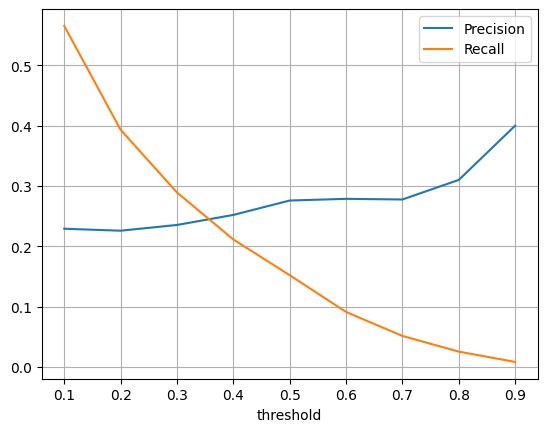

In [25]:
from sklearn.metrics import precision_score, recall_score

precisions = []
recalls = []
sigma = 22
seps = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for sep in seps:
  random_pairs_jaccard = []
  random_pairs_gaussian = []
  for pair in pairs:
    random_pairs_jaccard.append(scores_mol_similarity[pair[0], pair[1]])
    random_pairs_gaussian.append(vec_normalized_distance(spectrums[pair[0]].peaks.mz,
                                                        spectrums[pair[0]].peaks.intensities,
                                                        spectrums[pair[1]].peaks.mz,
                                                        spectrums[pair[1]].peaks.intensities, sigma))
  y_true = np.array(random_pairs_jaccard)
  y_pred = np.array(random_pairs_gaussian)

  threshold_true = 0.4
  threshold_pred = sep
  y_true_bin = (y_true >= threshold_true).astype(int)
  y_pred_bin = (y_pred >= threshold_pred).astype(int)
  precisions.append(precision_score(y_true_bin, y_pred_bin))
  recalls.append(recall_score(y_true_bin, y_pred_bin))

plt.plot(seps, precisions, label="Precision")
plt.plot(seps, recalls, label="Recall")
plt.legend()
plt.grid()
plt.xlabel("threshold")
plt.show()

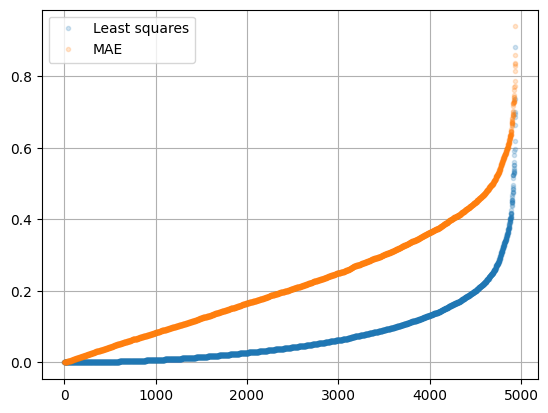

In [26]:
sigma = 22

random_pairs_jaccard = []
random_pairs_gaussian = []
for pair in pairs:
  random_pairs_jaccard.append(scores_mol_similarity[pair[0], pair[1]])
  random_pairs_gaussian.append(vec_normalized_distance(spectrums[pair[0]].peaks.mz,
                                                      spectrums[pair[0]].peaks.intensities,
                                                      spectrums[pair[1]].peaks.mz,
                                                      spectrums[pair[1]].peaks.intensities, sigma))
y_true = np.array(random_pairs_jaccard)
y_pred = np.array(random_pairs_gaussian)

# least squares on ytrue and ypred

lsq = (y_true - y_pred)**2
plt.plot(sorted(lsq), '.', alpha=0.2, label='Least squares')
plt.legend()

mae = np.abs(y_true - y_pred)
plt.plot(sorted(mae), '.', alpha=0.2, label='MAE')
plt.legend()

plt.grid()
plt.show()

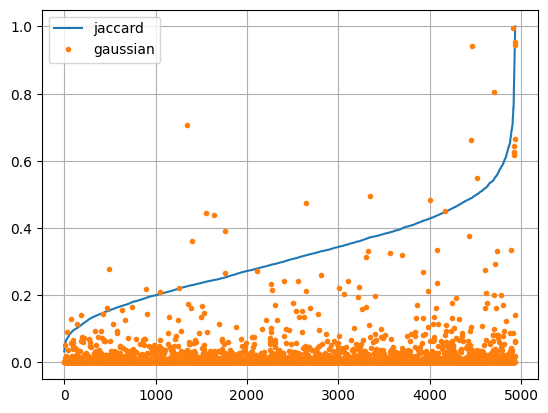

In [27]:
random_pairs_jaccard = []
random_pairs_gaussian = []
for pair in pairs:
  random_pairs_jaccard.append(scores_mol_similarity[pair[0], pair[1]])
  random_pairs_gaussian.append(vec_normalized_distance(spectrums[pair[0]].peaks.mz,
                                                      spectrums[pair[0]].peaks.intensities,
                                                      spectrums[pair[1]].peaks.mz,
                                                      spectrums[pair[1]].peaks.intensities, sigma=0.01))

idx = np.argsort(random_pairs_jaccard)
jaccard = np.array(random_pairs_jaccard)
gaussian = np.array(random_pairs_gaussian)
plt.plot(jaccard[idx], label="jaccard")
plt.plot(gaussian[idx], '.',label="gaussian")
plt.legend()
plt.grid()
plt.show()

### mixture of kernels

$$ k(p_i, p_j') = \sum_{r=1}^k \alpha_r \exp{\frac{- | p_i - p_j' |}{\sigma_r}}, \quad \sum_{r=1}^k \alpha_r = 1 $$
$$ K(X, Y) = \sum_{i=1}^{n} \sum_{j=1}^{m} w_i v_j k(X_i, Y_j) $$
$$ S(X, Y) = \frac{K(X, Y)}{K(X, X) + K(Y,Y) - K(X, Y)} $$
$$ \ell = \sum_{i=1}^{n} (S(X_i, Y_i) - J_i)^2$$
We want to solve the following optimization problem:
$$ \min_{\alpha, \sigma} \ell $$
$$ \text{s.t.} \sum_{r=1}^k \alpha_r = 1 $$

In [28]:
# Laplace kernel (vectorized)
def laplace_kernel(mz_x, mz_y, sigma):
    """
    mz_x: (n,)
    mz_y: (m,)
    sigma: float
    returns (n, m) kernel matrix
    """
    mz_x = np.asarray(mz_x)
    mz_y = np.asarray(mz_y)
    diff = mz_x[:, None] - mz_y[None, :]
    return np.exp(- np.abs(diff) / sigma)


def mixed_kernel_matrix(mz_x, mz_y, sigmas, alphas):
    """
    Returns combined kernel matrix K(x,y)
    """
    K = np.zeros((len(mz_x), len(mz_y)))

    for sigma, alpha in zip(sigmas, alphas):
        K += alpha * laplace_kernel(mz_x, mz_y, sigma)

    return K

def vec_similarity(mz_x, inten_x, mz_y, inten_y, sigmas, alphas):
    inten_x = np.asarray(inten_x)
    inten_y = np.asarray(inten_y)
    K = mixed_kernel_matrix(mz_x, mz_y, sigmas, alphas)
    return np.sum(K * inten_x[:, None] * inten_y[None, :])

def vec_mixture_tanimoto(mz_x, inten_x, mz_y, inten_y,
                         sigmas, alphas, eps=1e-12):

    K_xy = vec_similarity(mz_x, inten_x, mz_y, inten_y, sigmas, alphas)
    K_xx = vec_similarity(mz_x, inten_x, mz_x, inten_x, sigmas, alphas)
    K_yy = vec_similarity(mz_y, inten_y, mz_y, inten_y, sigmas, alphas)

    denom = K_xx + K_yy - K_xy

    return K_xy / (denom + eps)

In [29]:
laplace_kernel(mz_x=[1, 2, 3], mz_y=[1, 2, 3], sigma=1)

array([[1.        , 0.36787944, 0.13533528],
       [0.36787944, 1.        , 0.36787944],
       [0.13533528, 0.36787944, 1.        ]])

In [30]:
mixed_kernel_matrix(mz_x = [1, 2, 3], mz_y = [1, 2, 3], sigmas=[1, 2, 3], alphas=[0.2, 0.7, 0.1])

array([[1.        , 0.56980048, 0.33592438],
       [0.56980048, 1.        , 0.56980048],
       [0.33592438, 0.56980048, 1.        ]])

In [31]:
vec_similarity(mz_x = [1, 2, 3], inten_x = [0.2, 0.5, 0.3],
               mz_y = [2, 3, 8], inten_y = [0.5, 0.2, 0.3],
               sigmas=[1, 2, 3], alphas=[0.2, 0.7, 0.1])

np.float64(0.539052760348315)

In [32]:
vec_mixture_tanimoto(mz_x = [1, 2, 3], inten_x = [0.2, 0.5, 0.3],
               mz_y = [2, 3, 8], inten_y = [0.5, 0.2, 0.3],
               sigmas=[1, 2, 3], alphas=[0.2, 0.7, 0.1])

np.float64(0.7879668025872778)

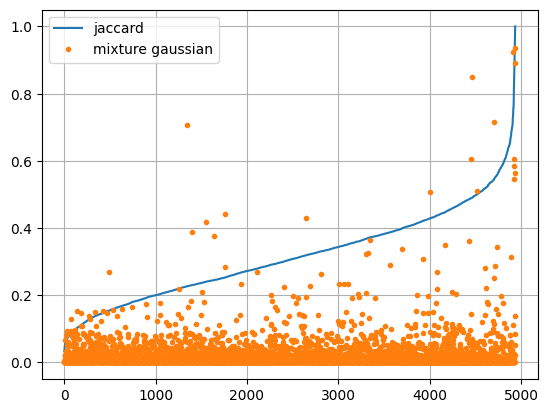

In [33]:
sigmas = np.logspace(-3, 0, 10)   # multi-scale
alphas = np.ones(len(sigmas)) / len(sigmas)  # uniform initial weights

random_pairs_jaccard = []
random_pairs_kernel = []

for pair in pairs:
    i, j = pair

    random_pairs_jaccard.append(scores_mol_similarity[i, j])

    sim = vec_mixture_tanimoto(
        spectrums[i].peaks.mz,
        spectrums[i].peaks.intensities,
        spectrums[j].peaks.mz,
        spectrums[j].peaks.intensities,
        sigmas=sigmas,
        alphas=alphas
    )

    random_pairs_kernel.append(sim)

jaccard = np.array(random_pairs_jaccard)
kernel = np.array(random_pairs_kernel)
idx = np.argsort(jaccard)

plt.plot(jaccard[idx], label="jaccard")
plt.plot(kernel[idx], '.',label="mixture gaussian")
plt.legend()
plt.grid()
plt.show()

In [34]:
# todo:
# train a model with jaccard as ground truth
# evaluate and validate the model

import torch
import torch.nn.functional as F

# Laplace kernel (broadcasted)
def laplace_kernel_torch(x, y, sigma):
    # x: (n,), y: (m,)
    diff = x[:, None] - y[None, :]
    return torch.exp(-torch.abs(diff) / sigma)

def mixed_kernel_matrix_torch(x, y, sigmas, alphas):
    K = 0.0
    for sigma, alpha in zip(sigmas, alphas):
        K = K + alpha * laplace_kernel_torch(x, y, sigma)
    return K

def vec_similarity_torch(mz_x, inten_x, mz_y, inten_y, sigmas, alphas):
    K = mixed_kernel_matrix_torch(mz_x, mz_y, sigmas, alphas)
    return torch.sum(K * inten_x[:, None] * inten_y[None, :])

def vec_tanimoto_torch(mz_x, inten_x, mz_y, inten_y, sigmas, alphas):
    K_xy = vec_similarity_torch(mz_x, inten_x, mz_y, inten_y, sigmas, alphas)
    K_xx = vec_similarity_torch(mz_x, inten_x, mz_x, inten_x, sigmas, alphas)
    K_yy = vec_similarity_torch(mz_y, inten_y, mz_y, inten_y, sigmas, alphas)
    return K_xy / torch.sqrt(K_xx * K_yy)

def loss_fn(dataset, sigmas, alphas):
    loss = 0.0
    for mz_x, inten_x, mz_y, inten_y, J in dataset:
        S = vec_tanimoto_torch(mz_x, inten_x, mz_y, inten_y, sigmas, alphas)
        loss = loss + torch.nn.functional.mse_loss(S, J)
    return loss

def get_params(a, s):
    alphas = F.softmax(a, dim=0)
    sigmas = torch.exp(s)
    return sigmas, alphas

In [35]:
R = 15  # number of parameters
a = torch.randn(R, requires_grad=True)  # unconstrained weights
s = torch.randn(R, requires_grad=True)  # log sigma

base_lr = 0.2
optimizer = torch.optim.Adam([a, s], lr=base_lr)
dataset = [
    (
        torch.tensor(spectrums[i].peaks.mz, dtype=torch.float32),
        torch.tensor(spectrums[i].peaks.intensities, dtype=torch.float32),
        torch.tensor(spectrums[j].peaks.mz, dtype=torch.float32),
        torch.tensor(spectrums[j].peaks.intensities, dtype=torch.float32),
        torch.tensor(scores_mol_similarity[i, j], dtype=torch.float32)
    )
    for i, j in pairs
]

for epoch in range(5):
    # lr = base_lr / (1 + 0.1 * epoch)  # simple decay rule

    # for param_group in optimizer.param_groups:
    #     param_group["lr"] = lr

    optimizer.zero_grad()

    sigmas, alphas = get_params(a, s)
    loss = loss_fn(dataset, sigmas, alphas)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, loss = {loss.item():.4f}")

Epoch 0, loss = 430.6848
Epoch 1, loss = 414.7882
Epoch 2, loss = 397.3174
Epoch 3, loss = 379.3017
Epoch 4, loss = 363.0305


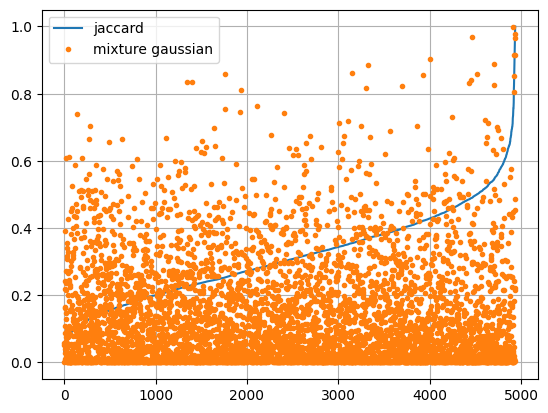

In [ ]:
random_pairs_jaccard = []
random_pairs_kernel = []

for pair in pairs:
    i, j = pair

    random_pairs_jaccard.append(scores_mol_similarity[i, j])

    sim = vec_tanimoto_torch(
        torch.tensor(spectrums[i].peaks.mz, dtype=torch.float32),
        torch.tensor(spectrums[i].peaks.intensities, dtype=torch.float32),
        torch.tensor(spectrums[j].peaks.mz, dtype=torch.float32),
        torch.tensor(spectrums[j].peaks.intensities, dtype=torch.float32),
        sigmas=sigmas,
        alphas=alphas
    )

    random_pairs_kernel.append(sim.detach().cpu().numpy())

jaccard = np.array(random_pairs_jaccard)
kernel = np.array(random_pairs_kernel)
idx = np.argsort(jaccard)

plt.plot(jaccard[idx], label="jaccard")
plt.plot(kernel[idx], '.',label="laplace mixture")
plt.legend()
plt.grid()
plt.show()